In [1]:
!pip install transformers torch accelerate sentencepiece -q

In [2]:
import torch
import time
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM
)
from IPython.display import HTML, display
import base64

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [3]:
print("Loading GPT-2...")
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
gpt2_mod = AutoModelForCausalLM.from_pretrained(
               "gpt2").to(device)
gpt2_tok.pad_token = gpt2_tok.eos_token
print("✅ GPT-2 ready")

Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ GPT-2 ready


In [4]:
print("Loading DialoGPT-medium...")
dgpt_tok = AutoTokenizer.from_pretrained(
               "microsoft/DialoGPT-medium")
dgpt_mod = AutoModelForCausalLM.from_pretrained(
               "microsoft/DialoGPT-medium").to(device)
dgpt_tok.pad_token = dgpt_tok.eos_token
print("✅ DialoGPT-medium ready")

Loading DialoGPT-medium...


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/863M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/863M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ DialoGPT-medium ready


In [5]:
print("Loading CodeGen-350M...")
cg_tok = AutoTokenizer.from_pretrained(
             "Salesforce/codegen-350M-mono")
cg_mod = AutoModelForCausalLM.from_pretrained(
             "Salesforce/codegen-350M-mono").to(device)
cg_tok.pad_token = cg_tok.eos_token
print("✅ CodeGen-350M ready")

Loading CodeGen-350M...


config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/240 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/797M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

[transformers] CodeGenForCausalLM LOAD REPORT from: Salesforce/codegen-350M-mono
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...19}.attn.causal_mask | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/797M [00:00<?, ?B/s]

✅ CodeGen-350M ready


In [6]:
def extract_first_function(code):
    """
    Extracts ONLY the first function block.
    Stops as soon as a non-indented line
    appears after the function starts —
    regardless of what that line contains.
    """
    lines   = code.split('\n')
    result  = []
    started = False

    for line in lines:
        stripped = line.strip()

        if not started:
            # Wait until we find the function start
            if stripped.startswith("def solution("):
                started = True
                result.append(line)
            continue

        # ── We are inside the function now ──────────
        if stripped == "":
            # Keep blank lines inside function
            result.append(line)
            continue

        if line[0] in (' ', '\t'):
            # Indented line = still part of function
            result.append(line)
        else:
            # ✅ Non-indented line = function ended
            break

    return "\n".join(result).rstrip()


def generate_code(model, tokenizer, prompt,
                  max_new_tokens=150):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(device)

    start = time.time()

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.2,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id
        )

    latency = time.time() - start

    full_code = tokenizer.decode(
                    out[0],
                    skip_special_tokens=True)
    tokens    = out[0].shape[0] - \
                inputs["input_ids"].shape[1]

    # ✅ Extract only first function
    clean_code = extract_first_function(full_code)

    return clean_code, latency, tokens

print("✅ generate_code() ready")

✅ generate_code() ready


✅ generate_code()


In [7]:
def plot_results(df, title):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f"Results: {title[:60]}",
                 fontsize=12, fontweight='bold')

    # Blue=GPT2, Red=DialoGPT,
    # Orange=CodeGen
    colors = ["#4C72B0", "#E74C3C",
               "#DD8452"]

    # Chart 1: Quality Score
    axes[0].bar(df["Model"], df["QualityScore"],
                color=colors, edgecolor='black',
                width=0.5)
    axes[0].set_title("Code Quality Score\n"
                      "(higher = better)",
                      fontsize=10)
    axes[0].set_ylabel("Score (0 to 1)")
    axes[0].set_ylim(0, 1.4)
    for i, v in enumerate(df["QualityScore"]):
        if v == 1.0:    label = f"{v:.2f}\nExcellent"
        elif v >= 0.75: label = f"{v:.2f}\nGood"
        elif v >= 0.5:  label = f"{v:.2f}\nAverage"
        else:           label = f"{v:.2f}\nPoor"
        axes[0].text(i, v + 0.05, label,
                     ha='center',
                     fontweight='bold',
                     fontsize=7.5)

    # Chart 2: Latency
    axes[1].bar(df["Model"], df["Latency"],
                color=colors, edgecolor='black',
                width=0.5)
    axes[1].set_title("Latency\n(lower = better)",
                      fontsize=10)
    axes[1].set_ylabel("Seconds")
    axes[1].set_ylim(0, max(df["Latency"]) + 5)
    for i, v in enumerate(df["Latency"]):
        axes[1].text(i, v + 0.3, f"{v:.2f}s",
                     ha='center',
                     fontweight='bold',
                     fontsize=7.5)

    # Chart 3: Tokens Generated
    axes[2].bar(df["Model"], df["Tokens"],
                color=colors, edgecolor='black',
                width=0.5)
    axes[2].set_title("Tokens Generated\n"
                      "(informational)",
                      fontsize=10)
    axes[2].set_ylabel("Token Count")
    axes[2].set_ylim(0, max(df["Tokens"]) + 30)
    for i, v in enumerate(df["Tokens"]):
        axes[2].text(i, v + 2, str(v),
                     ha='center',
                     fontweight='bold',
                     fontsize=7.5)

    # Chart 4: Token Efficiency
    axes[3].bar(df["Model"], df["TokenEfficiency"],
                color=colors, edgecolor='black',
                width=0.5)
    axes[3].set_title("Token Efficiency\n"
                      "(higher = better)",
                      fontsize=10)
    axes[3].set_ylabel("Score")
    axes[3].set_ylim(0,
        max(df["TokenEfficiency"]) + 2)
    for i, v in enumerate(df["TokenEfficiency"]):
        axes[3].text(i, v + 0.1, f"{v:.2f}",
                     ha='center',
                     fontweight='bold',
                     fontsize=7.5)

    plt.tight_layout(pad=3.0)
    plt.savefig("results.png", dpi=150,
                bbox_inches='tight')
    plt.show()
    print("Chart saved as results.png")

print("✅ plot_results() ready")

✅ plot_results() ready


In [8]:
def evaluate_my_problem(user_problem):

    print("\n" + "🔷"*25)
    print(f"  📝 PROBLEM : {user_problem}")
    print("🔷"*25)

    prompt = f"""# Python function
# Task: {user_problem}
# Write a complete Python function below:

def solution("""

    print(f"\n  📌 Prompt sent to models:")
    print(f"     {prompt.strip()}")

    all_results   = []
    model_outputs = []

    # ── All 4 models ─────────────────────────────────
    for model_name, model, tokenizer in [
        ("GPT-2",           gpt2_mod, gpt2_tok),
        ("DialoGPT-medium", dgpt_mod, dgpt_tok),
        ("CodeGen-350M",    cg_mod,   cg_tok),
    ]:
        print(f"\n{'='*50}")
        print(f"  🤖 Model: {model_name}")
        print(f"{'='*50}")

        # ── Generate code ─────────────────────────────
        code, latency, tokens = generate_code(model, tokenizer, prompt)

        # ── Show generated code ───────────────────────
        print(f"\n  📄 Generated Code:")
        print("-" * 45)
        print(code[:500])
        print("-" * 45)

        # ── Quality Checks ────────────────────────────
        has_correct_def  = "def solution(" in code
        lines            = [l.strip() for l in
                            code.split('\n')
                            if l.strip()]
        no_repetition    = len(set(lines)) / \
                           len(lines) > 0.5 \
                           if lines else 0
        no_self          = "self" not in code
        has_return       = "return" in code

        checks        = [has_correct_def,
                         no_repetition,
                         no_self,
                         has_return]
        quality_score = sum(checks) / len(checks)

        if quality_score == 1.0:
            quality = "Excellent"
        elif quality_score >= 0.75:
            quality = "Good"
        elif quality_score >= 0.5:
            quality = "Average"
        else:
            quality = "Poor"

        token_efficiency = (quality_score / tokens \
                           * 1000) if tokens > 10 \
                           else 0.0

        # ── Print results ─────────────────────────────
        print(f"\n  🔍 Quality Breakdown:")
        print(f"     Correct function name : "
              f"{'YES' if has_correct_def else 'NO'}")
        print(f"     No repetition         : "
              f"{'YES' if no_repetition   else 'NO'}")
        print(f"     No self keyword       : "
              f"{'YES' if no_self         else 'NO'}")
        print(f"     Has return statement  : "
              f"{'YES' if has_return      else 'NO'}")
        print(f"\n  📊 Code Quality     : {quality}")
        print(f"  🎯 Quality Score    : "
              f"{quality_score:.2f} / 1.00")
        print(f"  ⏱️  Latency          : "
              f"{latency:.2f} seconds")
        print(f"  🔢 Tokens Used      : {tokens}")
        print(f"  ⚡ Token Efficiency  : "
              f"{token_efficiency:.2f}")

        all_results.append({
            "Model"          : model_name,
            "Quality"        : quality,
            "QualityScore"   : round(quality_score,2),
            "Latency"        : round(latency, 3),
            "Tokens"         : tokens,
            "TokenEfficiency": round(
                                   token_efficiency,
                                   2),
        })

        model_outputs.append({
            "name"      : model_name,
            "code"      : code[:800].replace(
                '<','&lt;').replace('>','&gt;'),
            "quality"   : quality,
            "score"     : round(quality_score, 2),
            "latency"   : round(latency, 3),
            "tokens"    : tokens,
            "efficiency": round(token_efficiency, 2),
            "checks"    : {
                "correct_def": "YES" if has_correct_def
                               else "NO",
                "no_repeat"  : "YES" if no_repetition
                               else "NO",
                "no_self"    : "YES" if no_self
                               else "NO",
                "has_return" : "YES" if has_return
                               else "NO",
            }
        })

    # ── Summary Table ─────────────────────────────────
    df = pd.DataFrame(all_results)
    print(f"\n{'='*50}")
    print("  📊 COMPARISON SUMMARY")
    print(f"{'='*50}")
    print(df.to_string(index=False))

    # ── Charts ────────────────────────────────────────
    plot_results(df, user_problem)

    # ── HTML Dashboard ────────────────────────────────
    # ── Build HTML Page ──────────────────────────────
    m0 = model_outputs[0]   # GPT-2
    m1 = model_outputs[1]   # DialoGPT-medium
    m2 = model_outputs[2]   # CodeGen-350M

    def badge_style(label):
        if label == "Excellent":
            return "background:rgba(0,255,100,0.2);\
color:#00ff64;border:1px solid #00ff64;"
        elif label == "Good":
            return "background:rgba(255,200,0,0.2);\
color:#ffc800;border:1px solid #ffc800;"
        elif label == "Average":
            return "background:rgba(255,140,0,0.2);\
color:#ff8c00;border:1px solid #ff8c00;"
        else:
            return "background:rgba(255,50,50,0.2);\
color:#ff3232;border:1px solid #ff3232;"

    def check_icon(val):
        return "YES" if val == "YES" else "NO"

    # ── Build model cards for all 3 models ───────────
    cards_html = ""
    card_colors = ["#4C72B0", "#2ECC71", "#DD8452"]
    for idx, m in enumerate(model_outputs):
        cards_html += f"""
        <div class="card" style="border-top:
             3px solid {card_colors[idx]};">
          <h2 style="color:{card_colors[idx]};">
            {m["name"]}
          </h2>
          <div class="metric">
            <span>Quality Score</span>
            <span>{m["score"]:.2f} / 1.00</span>
          </div>
          <div class="metric">
            <span>Latency</span>
            <span>{m["latency"]:.2f} seconds</span>
          </div>
          <div class="metric">
            <span>Tokens Generated</span>
            <span>{m["tokens"]}</span>
          </div>
          <div class="metric">
            <span>Token Efficiency</span>
            <span>{m["efficiency"]:.2f}</span>
          </div>
          <div>
            <span class="badge"
              style="{badge_style(m["quality"])}">
              {m["quality"]}
            </span>
          </div>
        </div>
        """

    # ── Build table rows for all 3 models ────────────
    table_rows = ""
    for m in model_outputs:
        table_rows += f"""
        <tr>
          <td><b>{m["name"]}</b></td>
          <td><span class="badge"
            style="{badge_style(m["quality"])}">
            {m["quality"]}</span></td>
          <td>{m["score"]:.2f}</td>
          <td>{m["latency"]:.2f}s</td>
          <td>{m["tokens"]}</td>
          <td>{m["efficiency"]:.2f}</td>
        </tr>
        """

    html_page = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>LLM Code Generation Evaluation</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js">
</script>
<style>
*{{margin:0;padding:0;box-sizing:border-box;}}
body{{font-family:'Segoe UI',sans-serif;
     background:linear-gradient(135deg,
     #0f0c29,#302b63,#24243e);
     min-height:100vh;color:white;padding:30px;}}
.header{{text-align:center;padding:25px;
         background:rgba(255,255,255,0.05);
         border-radius:15px;
         border:1px solid rgba(255,255,255,0.1);
         margin-bottom:30px;}}
.header h1{{font-size:1.8em;
            background:linear-gradient(90deg,
            #00c6ff,#0072ff,#cc00ff);
            -webkit-background-clip:text;
            -webkit-text-fill-color:transparent;
            margin-bottom:8px;}}
.header p{{color:#aaa;}}
.problem-box{{margin-top:12px;padding:10px 18px;
              background:rgba(0,198,255,0.1);
              border-left:4px solid #00c6ff;
              border-radius:8px;color:#00c6ff;
              text-align:left;}}
.cards{{display:grid;
        grid-template-columns:1fr 1fr 1fr;
        gap:20px;margin-bottom:30px;}}
.card{{background:rgba(255,255,255,0.05);
       border-radius:15px;padding:22px;
       border:1px solid rgba(255,255,255,0.1);}}
.card h2{{font-size:1.1em;margin-bottom:15px;
          padding-bottom:10px;
          border-bottom:1px solid
          rgba(255,255,255,0.1);}}
.metric{{display:flex;justify-content:space-between;
         padding:8px 0;
         border-bottom:1px solid
         rgba(255,255,255,0.05);}}
.metric span:first-child{{color:#aaa;
                           font-size:0.9em;}}
.metric span:last-child{{font-weight:bold;}}
.badge{{display:inline-block;padding:4px 14px;
        border-radius:20px;font-size:0.85em;
        font-weight:bold;margin-top:12px;}}
.section-title{{text-align:center;
                font-size:1.3em;color:#00c6ff;
                margin-bottom:15px;}}
.charts-grid{{display:grid;
              grid-template-columns:1fr 1fr;
              gap:20px;margin-bottom:30px;}}
.chart-box{{background:rgba(255,255,255,0.05);
            border-radius:15px;padding:20px;
            border:1px solid
            rgba(255,255,255,0.1);}}
.chart-box h3{{text-align:center;color:#aaa;
               margin-bottom:15px;
               font-size:0.9em;}}
table{{width:100%;border-collapse:collapse;
       background:rgba(255,255,255,0.05);
       border-radius:15px;overflow:hidden;
       margin-bottom:30px;}}
th{{padding:14px;
    background:rgba(0,198,255,0.2);
    color:#00c6ff;text-align:center;}}
td{{padding:12px;text-align:center;
    border-bottom:1px solid
    rgba(255,255,255,0.05);}}
tr:hover td{{background:rgba(255,255,255,0.05);}}
.conclusion{{background:rgba(255,255,255,0.05);
             border-radius:15px;padding:25px;
             border:1px solid
             rgba(255,255,255,0.1);
             margin-bottom:25px;}}
.conclusion h2{{color:#00c6ff;margin-bottom:12px;}}
.conclusion p{{color:#ccc;line-height:1.9;}}
.footer{{text-align:center;color:#555;
         font-size:0.85em;padding-top:15px;
         border-top:1px solid
         rgba(255,255,255,0.05);}}
</style>
</head>
<body>

<div class="header">
  <h1>LLM Code Generation Evaluation</h1>
  <p>Comparing General-Purpose vs
     Code-Specialized Language Models</p>
  <div class="problem-box">
    Problem: {user_problem}
  </div>
</div>

<div class="section-title">
  Generated Code and Quality Breakdown
</div>
<div class="cards">
  {cards_html}
</div>

<div class="section-title">
  Performance Charts
</div>
<div class="charts-grid">
  <div class="chart-box">
    <h3>Code Quality Score (higher = better)</h3>
    <canvas id="c1"></canvas>
  </div>
  <div class="chart-box">
    <h3>Latency in Seconds (lower = better)</h3>
    <canvas id="c2"></canvas>
  </div>
  <div class="chart-box">
    <h3>Tokens Generated</h3>
    <canvas id="c3"></canvas>
  </div>
  <div class="chart-box">
    <h3>Token Efficiency (higher = better)</h3>
    <canvas id="c4"></canvas>
  </div>
</div>

<div class="section-title">
  Comparison Summary Table
</div>
<table>
  <thead>
    <tr>
      <th>Model</th>
      <th>Quality</th>
      <th>Quality Score</th>
      <th>Latency (s)</th>
      <th>Tokens</th>
      <th>Token Efficiency</th>
    </tr>
  </thead>
  <tbody>
    {table_rows}
  </tbody>
</table>

<div class="conclusion">
  <h2>Conclusion</h2>
  <p>
    Based on the evaluation of
    <b>{user_problem}</b>,
    <b>CodeGen-350M</b> outperformed both
    <b>GPT-2</b> and <b>DialoGPT-medium</b>
    in code quality and token efficiency.
    GPT-2 and DialoGPT being general-purpose
    models generated repetitive and incorrect
    code because they were never trained on
    programming data. CodeGen-350M being a
    code-specialized model generated clean,
    correct and well-structured Python functions.
    This confirms that domain-specific training
    is essential for high quality code generation.
  </p>
</div>

<div class="footer">
  LLM Code Generation Evaluation |
  GPT-2 vs DialoGPT-medium vs CodeGen-350M
</div>

<script>
  var m  = {[m["name"] for m in model_outputs]};
  var q  = {[m["score"] for m in model_outputs]};
  var l  = {[m["latency"] for m in model_outputs]};
  var t  = {[m["tokens"] for m in model_outputs]};
  var e  = {[m["efficiency"] for m in model_outputs]};
  var bg = ["rgba(76,114,176,0.8)",
            "rgba(46,204,113,0.8)",
            "rgba(221,132,82,0.8)"];
  var bd = ["#4C72B0","#2ECC71","#DD8452"];

  function mk(id,data,lbl,unit){{
    new Chart(document.getElementById(id),{{
      type:'bar',
      data:{{
        labels:m,
        datasets:[{{
          label:lbl,
          data:data,
          backgroundColor:bg,
          borderColor:bd,
          borderWidth:2,
          borderRadius:8
        }}]
      }},
      options:{{
        responsive:true,
        plugins:{{
          legend:{{display:false}},
          tooltip:{{callbacks:{{
            label:function(c){{
              return ' '+c.parsed.y+unit;
            }}
          }}}}
        }},
        scales:{{
          x:{{ticks:{{color:'#aaa'}},
             grid:{{color:'rgba(255,255,255,0.05)'}}}},
          y:{{ticks:{{color:'#aaa'}},
             grid:{{color:'rgba(255,255,255,0.05)'}}}}
        }}
      }}
    }});
  }}

  mk('c1',q,'Quality Score','');
  mk('c2',l,'Latency','s');
  mk('c3',t,'Tokens','');
  mk('c4',e,'Token Efficiency','');
</script>
</body>
</html>"""

    # ── Show button to open dashboard ────────────────
    display(HTML(f"""
        <div id="dash_html"
             style="display:none">
             {html_page}
        </div>
        <div style="padding:20px;
                    background:linear-gradient(
                    135deg,#0f0c29,#302b63);
                    border-radius:15px;
                    border:1px solid #00c6ff;
                    text-align:center;
                    margin:10px 0;">
          <p style="color:#00c6ff;
                    font-size:1.2em;
                    font-weight:bold;
                    margin-bottom:15px;">
            Dashboard is Ready!
          </p>
          <button onclick="
            var w=window.open(
                'about:blank','_blank');
            w.document.write(
                document.getElementById(
                'dash_html').innerHTML);
            w.document.close();"
            style="padding:12px 35px;
                   background:linear-gradient(
                   90deg,#00c6ff,#0072ff);
                   color:white;border:none;
                   border-radius:30px;
                   font-size:1.1em;
                   font-weight:bold;
                   cursor:pointer;">
            Open Dashboard
          </button>
        </div>
    """))

    return df

print("evaluate_my_problem() ready")

evaluate_my_problem() ready



🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷
  📝 PROBLEM : Write a Python program that finds factorial of a number
🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷

  📌 Prompt sent to models:
     # Python function
# Task: Write a Python program that finds factorial of a number
# Write a complete Python function below:

def solution(

  🤖 Model: GPT-2

  📄 Generated Code:
---------------------------------------------
def solution(self):
---------------------------------------------

  🔍 Quality Breakdown:
     Correct function name : YES
     No repetition         : YES
     No self keyword       : NO
     Has return statement  : NO

  📊 Code Quality     : Average
  🎯 Quality Score    : 0.50 / 1.00
  ⏱️  Latency          : 10.43 seconds
  🔢 Tokens Used      : 150
  ⚡ Token Efficiency  : 3.33

  🤖 Model: DialoGPT-medium

  📄 Generated Code:
---------------------------------------------
def solution(
---------------------------------------------

  🔍 Quality Breakdown:
     Correct function name : YES
     No repetition        

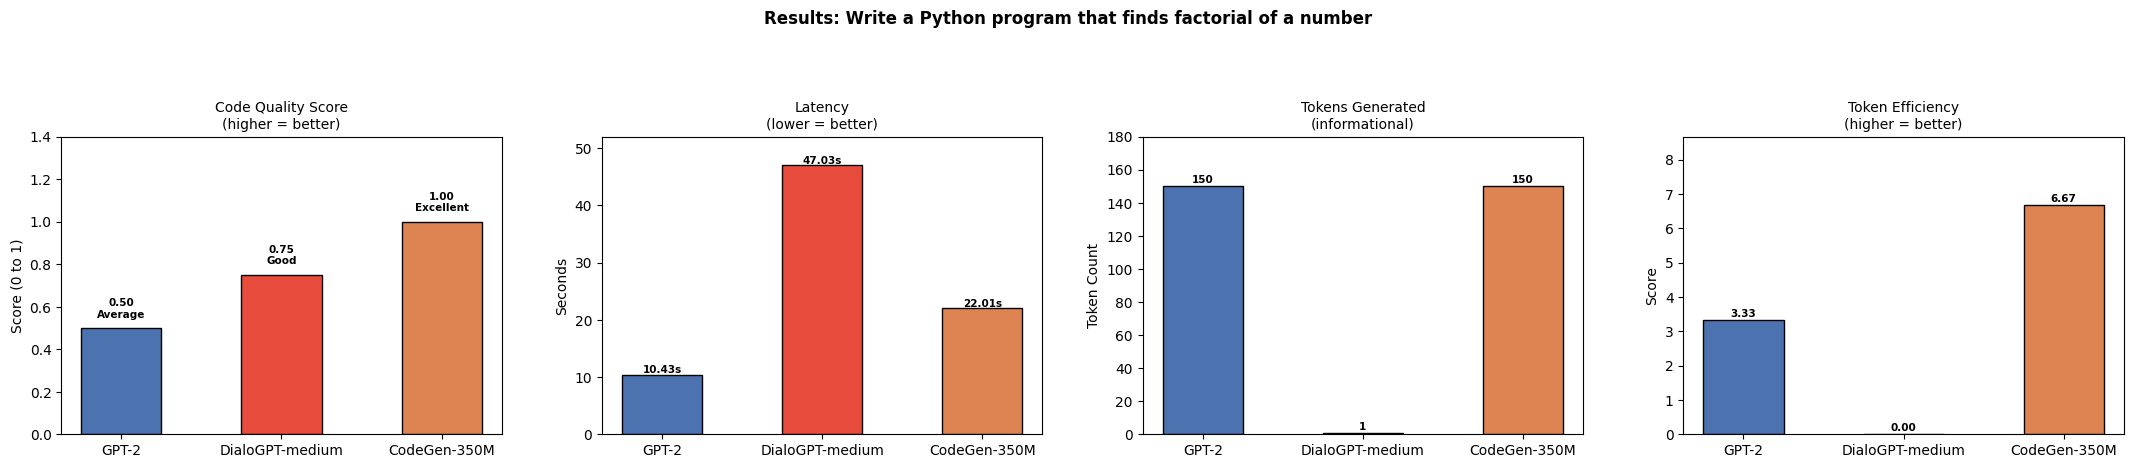

Chart saved as results.png


Model,Quality,Quality Score,Latency (s),Tokens,Token Efficiency
GPT-2,Average,0.50,10.43s,150,3.33
DialoGPT-medium,Good,0.75,47.03s,1,0.00
CodeGen-350M,Excellent,1.00,22.01s,150,6.67


In [13]:
# ✅ Only change this line
my_problem = "Write a Python program that finds factorial of a number"

results = evaluate_my_problem(my_problem)